# Разбор Иерархического Pipeline

Цель:
- Проверить состояние `hierarchical` pipeline по stage-level benchmark артефактам.
- Свести в одно место `accuracy`, `balanced_accuracy`, `macro_f1`, runtime и баланс целевых классов.
- Подтянуть текущий host-source как отдельный контекстный слой, но не смешивать его с итоговой физикой и final decision.
- Зафиксировать, где pipeline уже стабилен, а где нужен следующий проход до `end-to-end` decision run.

In [1]:
# Настройка: корень репозитория, sys.path и базовые визуальные настройки.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень репозитория из текущей рабочей директории.')


REPO_ROOT = find_repo_root(Path.cwd()).resolve()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

None

In [2]:
# Импортируем review-хелперы после добавления src в sys.path.
from exohost.reporting.host_training_review import (
    build_host_class_distribution_frame,
    build_host_class_stage_crosstab_frame,
    build_host_stage_distribution_frame,
    build_host_training_summary_frame,
    load_host_training_review_frame,
)
from exohost.reporting.model_pipeline_review import (
    build_benchmark_summary_frame,
    build_model_artifact_summary_frame,
    build_pipeline_stage_overview_frame,
    build_split_metrics_frame,
    build_stage_metric_long_frame,
    build_target_distribution_frame,
    build_threshold_artifact_summary_frame,
    load_benchmark_review_bundle,
)
from exohost.reporting.notebook_display import rename_frame_for_display
from exohost.reporting.notebook_labels import (
    PIPELINE_FINDING_LABELS,
    PIPELINE_RUNTIME_LABELS,
    PIPELINE_STAGE_METRIC_LABELS,
)


## План

- Загружаем benchmark artifacts по ключевым stage: `id_ood`, `coarse`, `refinement`.
- Строим единый обзор по test- и CV-метрикам.
- Отдельно смотрим баланс target-ов, чтобы понимать, где метрики проседают из-за support tail.
- Подключаем текущий host-source как отдельный контекстный слой, без смешивания с final decision review.
- Если заданы saved model или threshold artifacts, подтягиваем и их как дополнительный observability-слой.
- В конце формулируем короткий инженерный вывод перед `end-to-end` decision run.

In [3]:
# Конфигурация ноутбук.
STAGE_RUN_DIRS: dict[str, Path] = {
    'id_ood': REPO_ROOT / 'artifacts/benchmarks/gaia_id_ood_classification_2026_03_28_172217_384006',
    'coarse': REPO_ROOT / 'artifacts/benchmarks/gaia_id_coarse_classification_2026_03_28_171258_103400',
    'refinement_flat': REPO_ROOT / 'artifacts/benchmarks/gaia_mk_refinement_classification_2026_03_28_172145_781713',
    'host_field': REPO_ROOT / 'artifacts/benchmarks/host_field_classification_2026_03_29_071615_364867',
}
OPTIONAL_MODEL_RUN_DIRS: dict[str, Path] = {
    'ood_model': REPO_ROOT / 'artifacts/models/gaia_id_ood_classification__hist_gradient_boosting_calibrated_sigmoid__2026_03_28_215240_816364',
    'coarse_model': REPO_ROOT / 'artifacts/models/gaia_id_coarse_classification__hist_gradient_boosting__2026_03_28_215003_509969',
    'refinement_a_model': REPO_ROOT / 'artifacts/models/gaia_mk_refinement_a_classification__hist_gradient_boosting__2026_03_28_215244_571356',
    'refinement_b_model': REPO_ROOT / 'artifacts/models/gaia_mk_refinement_b_classification__hist_gradient_boosting__2026_03_28_215256_137842',
    'refinement_f_model': REPO_ROOT / 'artifacts/models/gaia_mk_refinement_f_classification__hist_gradient_boosting__2026_03_28_215300_779017',
    'refinement_g_model': REPO_ROOT / 'artifacts/models/gaia_mk_refinement_g_classification__hist_gradient_boosting__2026_03_28_215304_080764',
    'refinement_k_model': REPO_ROOT / 'artifacts/models/gaia_mk_refinement_k_classification__hist_gradient_boosting__2026_03_28_215308_148605',
    'refinement_m_model': REPO_ROOT / 'artifacts/models/gaia_mk_refinement_m_classification__hist_gradient_boosting__2026_03_28_215316_508533',
    'host_model': REPO_ROOT / 'artifacts/models/host_field_classification__hist_gradient_boosting__2026_03_29_071601_090632',
}
OPTIONAL_THRESHOLD_RUN_DIR: Path | None = REPO_ROOT / 'artifacts/thresholds/gaia_id_ood_classification__hist_gradient_boosting_calibrated_sigmoid__threshold__2026_03_28_215240_850166'
TARGET_SPLIT_NAME = 'full'
TOP_TARGET_LABELS = 15

for run_dir in STAGE_RUN_DIRS.values():
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)
for run_dir in OPTIONAL_MODEL_RUN_DIRS.values():
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)
if OPTIONAL_THRESHOLD_RUN_DIR is not None and not OPTIONAL_THRESHOLD_RUN_DIR.exists():
    raise FileNotFoundError(OPTIONAL_THRESHOLD_RUN_DIR)

HOST_SOURCE_LIMIT: int | None = None


In [4]:
# Загружаем stage bundles, host context и собираем общие summary tables.
stage_bundles = {
    stage_name: load_benchmark_review_bundle(run_dir)
    for stage_name, run_dir in STAGE_RUN_DIRS.items()
}
stage_overview_df = build_pipeline_stage_overview_frame(STAGE_RUN_DIRS)
stage_metric_long_df = build_stage_metric_long_frame(stage_overview_df)
target_distribution_frames = {
    stage_name: build_target_distribution_frame(bundle, split_name=TARGET_SPLIT_NAME)
    for stage_name, bundle in stage_bundles.items()
}

model_artifact_summary_df = (
    build_model_artifact_summary_frame(OPTIONAL_MODEL_RUN_DIRS)
    if OPTIONAL_MODEL_RUN_DIRS
    else pd.DataFrame()
)
threshold_artifact_summary_df = (
    build_threshold_artifact_summary_frame(OPTIONAL_THRESHOLD_RUN_DIR)
    if OPTIONAL_THRESHOLD_RUN_DIR is not None
    else pd.DataFrame()
)

host_review_status_df = pd.DataFrame()
host_summary_df = pd.DataFrame()
host_class_distribution_df = pd.DataFrame()
host_stage_distribution_df = pd.DataFrame()
host_class_stage_crosstab_df = pd.DataFrame()
try:
    host_review_df = load_host_training_review_frame(limit=HOST_SOURCE_LIMIT)
    host_summary_df = build_host_training_summary_frame(host_review_df)
    host_class_distribution_df = build_host_class_distribution_frame(host_review_df)
    host_stage_distribution_df = build_host_stage_distribution_frame(host_review_df)
    host_class_stage_crosstab_df = build_host_class_stage_crosstab_frame(host_review_df)
except RuntimeError as exc:
    host_review_status_df = pd.DataFrame([
        {
            'status': 'host_source_unavailable',
            'note': str(exc),
        }
    ])

display(
    rename_frame_for_display(
        stage_overview_df,
        column_mapping={
            'stage_name': 'Этап',
            'task_name': 'Задача',
            'run_dir': 'Каталог запуска',
            'created_at_utc': 'Время создания UTC',
            'n_rows_full': 'Число строк всего',
            'n_rows_train': 'Число строк train',
            'n_rows_test': 'Число строк test',
            'best_test_model': 'Лучшая модель на тесте',
            'test_accuracy': 'Точность на тесте (accuracy)',
            'test_balanced_accuracy': 'Сбалансированная точность на тесте',
            'test_macro_f1': 'Macro F1 на тесте',
            'test_roc_auc_ovr': 'ROC AUC OvR на тесте',
            'best_cv_model': 'Лучшая модель по CV',
            'cv_folds': 'Число fold в CV',
            'cv_mean_accuracy': 'Средняя точность CV (accuracy)',
            'cv_mean_balanced_accuracy': 'Средняя сбалансированная точность CV',
            'cv_mean_macro_f1': 'Средний Macro F1 CV',
            'fit_seconds': 'Время обучения',
            'cv_seconds': 'Время кросс-валидации',
            'total_seconds': 'Общее время',
        },
    )
)
if not model_artifact_summary_df.empty:
    display(model_artifact_summary_df)
if not threshold_artifact_summary_df.empty:
    display(threshold_artifact_summary_df)
if not host_review_status_df.empty:
    display(
        rename_frame_for_display(
            host_review_status_df,
            column_mapping={'status': 'Статус', 'note': 'Комментарий'},
        )
    )
else:
    display(
        rename_frame_for_display(
            host_summary_df,
            column_mapping={
                'n_rows': 'Число строк',
                'n_unique_source_id': 'Уникальные source_id',
                'n_unique_hostname': 'Уникальные host-имена',
                'n_spec_subclass_rows': 'Строк с подклассом',
                'n_supported_classes': 'Поддержанные спектральные классы',
                'n_supported_stages': 'Поддержанные стадии эволюции',
            },
        )
    )


,Этап,Задача,Каталог запуска,Время создания UTC,Число строк всего,Число строк train,Число строк test,Лучшая модель на тесте,Точность на тесте (accuracy),Сбалансированная точность на тесте,Macro F1 на тесте,ROC AUC OvR на тесте,Лучшая модель по CV,Число fold в CV,Средняя точность CV (accuracy),Средняя сбалансированная точность CV,Средний Macro F1 CV,Время обучения,Время кросс-валидации,Общее время
0,id_ood,gaia_id_ood_classification,gaia_id_ood_classification_2026_03_28_172217_3...,2026-03-28T17:22:17.384006+00:00,170333,119233,51100,hist_gradient_boosting,0.995734,0.926215,0.944521,0.996188,hist_gradient_boosting,10,0.996025,0.926544,0.947880,0.726418,7.451737,8.178155
1,coarse,gaia_id_coarse_classification,gaia_id_coarse_classification_2026_03_28_17125...,2026-03-28T17:12:58.103400+00:00,32986,23090,9896,hist_gradient_boosting,0.992926,0.992379,0.992573,0.999977,hist_gradient_boosting,10,0.992724,0.991869,0.991819,1.694207,16.595377,18.289584
2,refinement_flat,gaia_mk_refinement_classification,gaia_mk_refinement_classification_2026_03_28_1...,2026-03-28T17:21:45.781713+00:00,155326,108728,46598,hist_gradient_boosting,0.320336,0.187861,0.189683,0.713111,hist_gradient_boosting,10,0.323909,0.194267,0.194240,5.030338,46.906190,51.936528
3,host_field,host_field_classification,host_field_classification_2026_03_29_071615_36...,2026-03-29T07:16:15.364867+00:00,7406,5184,2222,hist_gradient_boosting,0.955446,0.955446,0.955442,0.990521,hist_gradient_boosting,10,0.946758,0.946763,0.946732,3.680408,14.009850,17.690259


,stage_name,run_dir,task_name,model_name,target_column,n_features,feature_columns_preview,created_at_utc
0,ood_model,gaia_id_ood_classification__hist_gradient_boos...,gaia_id_ood_classification,hist_gradient_boosting_calibrated_sigmoid,domain_target,8,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:52:40.816364+00:00
1,coarse_model,gaia_id_coarse_classification__hist_gradient_b...,gaia_id_coarse_classification,hist_gradient_boosting,spec_class,8,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:50:03.509969+00:00
2,refinement_a_model,gaia_mk_refinement_a_classification__hist_grad...,gaia_mk_refinement_a_classification,hist_gradient_boosting,spectral_subclass,11,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:52:44.571356+00:00
3,refinement_b_model,gaia_mk_refinement_b_classification__hist_grad...,gaia_mk_refinement_b_classification,hist_gradient_boosting,spectral_subclass,11,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:52:56.137842+00:00
4,refinement_f_model,gaia_mk_refinement_f_classification__hist_grad...,gaia_mk_refinement_f_classification,hist_gradient_boosting,spectral_subclass,11,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:53:00.779017+00:00
5,refinement_g_model,gaia_mk_refinement_g_classification__hist_grad...,gaia_mk_refinement_g_classification,hist_gradient_boosting,spectral_subclass,11,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:53:04.080764+00:00
6,refinement_k_model,gaia_mk_refinement_k_classification__hist_grad...,gaia_mk_refinement_k_classification,hist_gradient_boosting,spectral_subclass,11,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:53:08.148605+00:00
7,refinement_m_model,gaia_mk_refinement_m_classification__hist_grad...,gaia_mk_refinement_m_classification,hist_gradient_boosting,spectral_subclass,11,"teff_gspphot, logg_gspphot, mh_gspphot, bp_rp,...",2026-03-28T21:53:16.508533+00:00
8,host_model,host_field_classification__hist_gradient_boost...,host_field_classification,hist_gradient_boosting,host_label,8,"teff_gspphot, logg_gspphot, radius_gspphot, pa...",2026-03-29T07:16:01.090632+00:00


,run_dir,task_name,model_name,threshold_name,threshold_value,candidate_ood_threshold,threshold_metric,threshold_fit_scope,threshold_policy_version,created_at_utc
0,gaia_id_ood_classification__hist_gradient_boos...,gaia_id_ood_classification,hist_gradient_boosting_calibrated_sigmoid,tuned_threshold,0.012455,<NA>,balanced_accuracy,cv_5,id_ood_threshold_v1,2026-03-28T21:52:40.850166+00:00


,Число строк,Уникальные source_id,Уникальные host-имена,Строк с подклассом,Поддержанные спектральные классы,Поддержанные стадии эволюции
0,3729,3729,3729,0,6,2


Стадия эволюции,dwarf,evolved
Спектральный класс,,
A,15,5
B,4,2
F,411,60
G,1830,115
K,925,133
M,221,8


,Спектральный класс,Число строк,Доля
0,G,1945,0.521588
1,K,1058,0.283722
2,F,471,0.126307
3,M,229,0.061411
4,A,20,0.005363
5,B,6,0.001609


,Стадия эволюции,Число строк,Доля
0,dwarf,3406,0.913382
1,evolved,323,0.086618


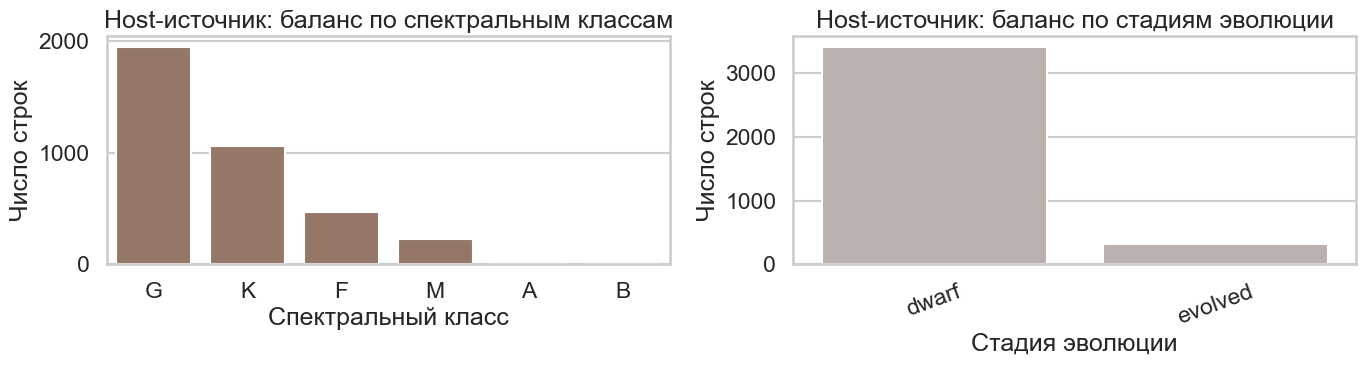

In [5]:
# Текущий контекст host-источника: отдельно от итогового обзора final decision.
if host_review_status_df.empty:
    display(host_class_stage_crosstab_df.rename_axis(index='Спектральный класс', columns='Стадия эволюции'))
    display(
        rename_frame_for_display(
            host_class_distribution_df,
            column_mapping={'spec_class': 'Спектральный класс', 'n_rows': 'Число строк', 'share': 'Доля'},
        )
    )
    display(
        rename_frame_for_display(
            host_stage_distribution_df,
            column_mapping={'evolution_stage': 'Стадия эволюции', 'n_rows': 'Число строк', 'share': 'Доля'},
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=host_class_distribution_df, x='spec_class', y='n_rows', ax=axes[0], color='#9C755F')
    axes[0].set_title('Host-источник: баланс по спектральным классам')
    axes[0].set_xlabel('Спектральный класс')
    axes[0].set_ylabel('Число строк')

    sns.barplot(data=host_stage_distribution_df, x='evolution_stage', y='n_rows', ax=axes[1], color='#BAB0AC')
    axes[1].set_title('Host-источник: баланс по стадиям эволюции')
    axes[1].set_xlabel('Стадия эволюции')
    axes[1].set_ylabel('Число строк')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()
else:
    print('Host-источник в текущем окружении недоступен, поэтому notebook остается только обзором pipeline.')


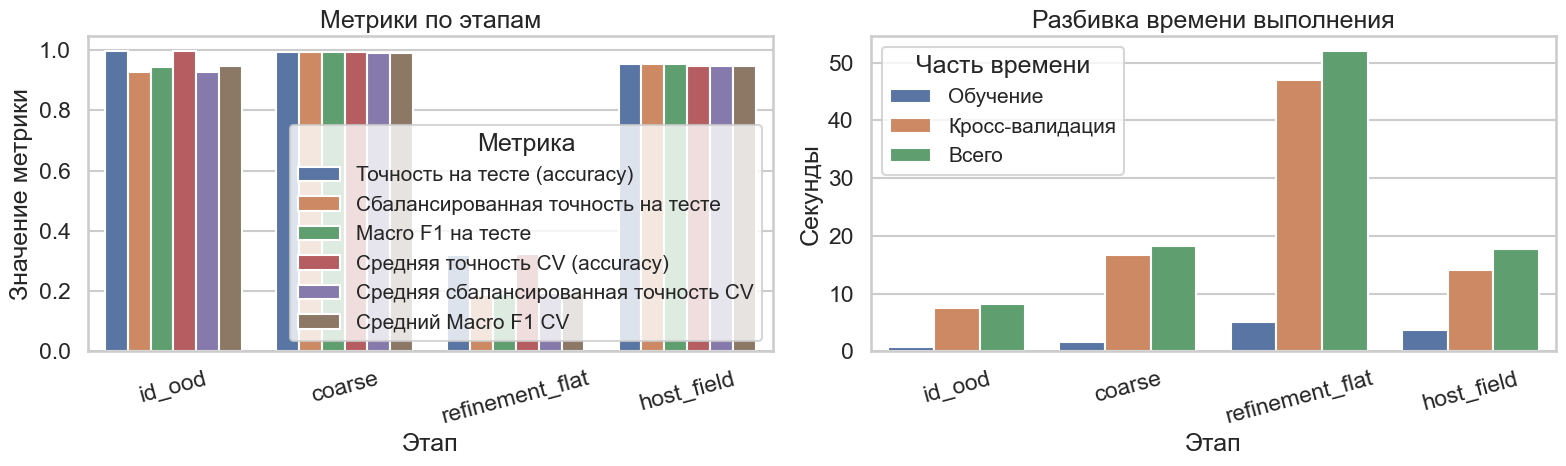

In [6]:
# Визуальный обзор: сравниваем ключевые stage-метрики и runtime.
plot_metric_names = [
    'test_accuracy',
    'test_balanced_accuracy',
    'test_macro_f1',
    'cv_mean_accuracy',
    'cv_mean_balanced_accuracy',
    'cv_mean_macro_f1',
]
plot_metric_df = stage_metric_long_df.loc[
    stage_metric_long_df['metric_name'].isin(plot_metric_names)
].copy()
plot_metric_df['metric_name'] = plot_metric_df['metric_name'].map(
    lambda value: PIPELINE_STAGE_METRIC_LABELS.get(str(value), str(value))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=plot_metric_df, x='stage_name', y='metric_value', hue='metric_name', ax=axes[0])
axes[0].set_title('Метрики по этапам')
axes[0].set_xlabel('Этап')
axes[0].set_ylabel('Значение метрики')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Метрика', loc='lower right', fontsize='small')

runtime_df = stage_overview_df.loc[:, ['stage_name', 'fit_seconds', 'cv_seconds', 'total_seconds']].melt(
    id_vars='stage_name',
    var_name='runtime_name',
    value_name='seconds',
)
runtime_df['runtime_name'] = runtime_df['runtime_name'].map(
    lambda value: PIPELINE_RUNTIME_LABELS.get(str(value), str(value))
)
sns.barplot(data=runtime_df, x='stage_name', y='seconds', hue='runtime_name', ax=axes[1])
axes[1].set_title('Разбивка времени выполнения')
axes[1].set_xlabel('Этап')
axes[1].set_ylabel('Секунды')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Часть времени', loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()


=== id_ood / выборка full ===


,split_name,Целевая метка,Число строк,Доля
0,full,id,166847,0.979534
1,full,ood,3486,0.020466


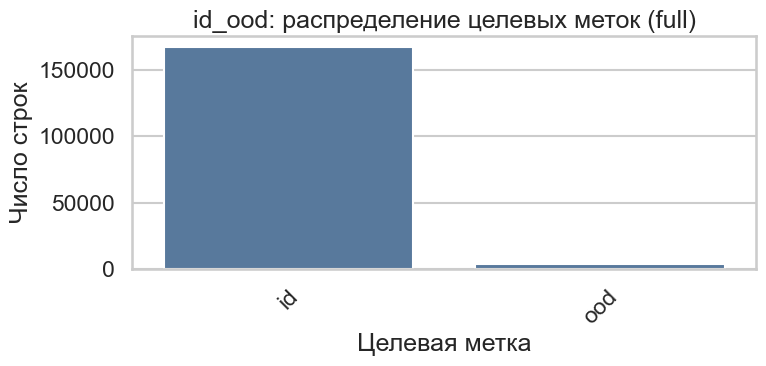

=== coarse / выборка full ===


,split_name,Целевая метка,Число строк,Доля
0,full,F,6000,0.181895
1,full,G,6000,0.181895
2,full,K,6000,0.181895
3,full,M,5986,0.181471
4,full,A,3000,0.090948
5,full,B,3000,0.090948
6,full,O,3000,0.090948


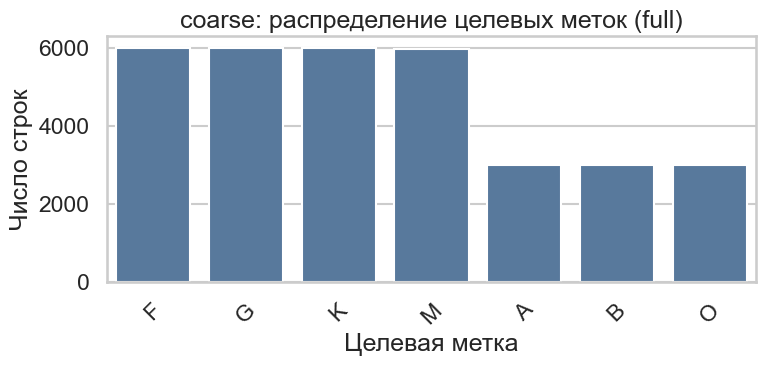

=== refinement_flat / выборка full ===


,split_name,Целевая метка,Число строк,Доля
0,full,K0,13158,0.084712
1,full,G0,9966,0.064162
2,full,F8,9749,0.062765
3,full,F5,9285,0.059778
4,full,G5,8508,0.054775
5,full,A0,8021,0.051640
6,full,G8,7617,0.049039
7,full,F0,5591,0.035995
8,full,A2,5544,0.035693
9,full,F2,5541,0.035673


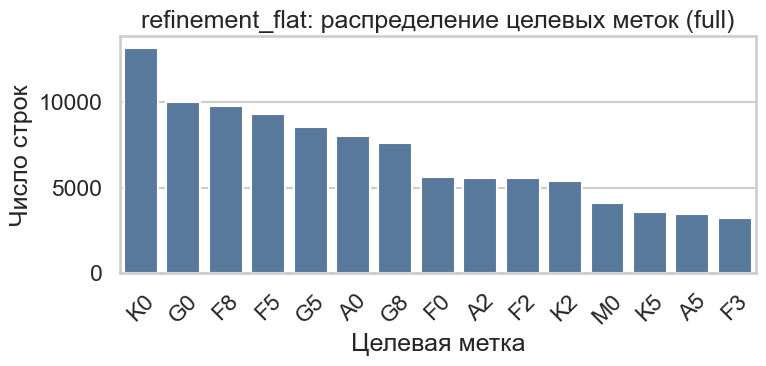

=== host_field / выборка full ===


,split_name,Целевая метка,Число строк,Доля
0,full,field,3703,0.5
1,full,host,3703,0.5


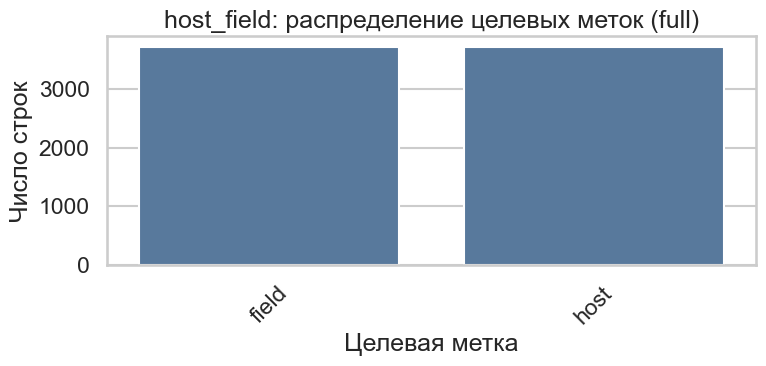

In [7]:
# Баланс целевых меток по каждому этапу.
for stage_name, target_df in target_distribution_frames.items():
    if target_df.empty:
        continue

    print(f'=== {stage_name} / выборка {TARGET_SPLIT_NAME} ===')
    preview_df = target_df.head(TOP_TARGET_LABELS).copy()
    display(
        rename_frame_for_display(
            preview_df,
            column_mapping={'target_label': 'Целевая метка', 'n_rows': 'Число строк', 'share': 'Доля'},
        )
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=preview_df, x='target_label', y='n_rows', ax=ax, color='#4C78A8')
    ax.set_title(f'{stage_name}: распределение целевых меток ({TARGET_SPLIT_NAME})')
    ax.set_xlabel('Целевая метка')
    ax.set_ylabel('Число строк')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


In [8]:
# Детальные метрики по stage для review и выводов.
detailed_metric_frames = []
for stage_name, bundle in stage_bundles.items():
    detailed_df = build_split_metrics_frame(bundle).copy()
    detailed_df.insert(0, 'stage_name', stage_name)
    detailed_metric_frames.append(detailed_df)

detailed_metrics_df = pd.concat(detailed_metric_frames, ignore_index=True)
display(
    rename_frame_for_display(
        detailed_metrics_df,
        column_mapping={
            'stage_name': 'Этап',
            'model_name': 'Модель',
            'split_name': 'Разбиение',
            'n_rows': 'Число строк',
            'n_classes': 'Число классов',
            'accuracy': 'Точность (accuracy)',
            'balanced_accuracy': 'Сбалансированная точность',
            'macro_precision': 'Macro precision',
            'macro_recall': 'Macro recall',
            'macro_f1': 'Macro F1',
            'roc_auc_ovr': 'ROC AUC OvR',
        },
    )
)

best_stage_row = stage_overview_df.sort_values(
    ['test_macro_f1', 'test_accuracy', 'test_balanced_accuracy'],
    ascending=[False, False, False],
    kind='mergesort',
    ignore_index=True,
).iloc[0]
worst_stage_row = stage_overview_df.sort_values(
    ['test_macro_f1', 'test_accuracy', 'test_balanced_accuracy'],
    ascending=[True, True, True],
    kind='mergesort',
    ignore_index=True,
).iloc[0]
slowest_stage_row = stage_overview_df.sort_values(
    ['total_seconds'],
    ascending=[False],
    kind='mergesort',
    ignore_index=True,
).iloc[0]

notebook_findings_df = pd.DataFrame(
    [
        {
            'finding_name': 'best_stage_by_macro_f1',
            'finding_value': f"{best_stage_row['stage_name']} ({best_stage_row['test_macro_f1']:.4f})",
        },
        {
            'finding_name': 'worst_stage_by_macro_f1',
            'finding_value': f"{worst_stage_row['stage_name']} ({worst_stage_row['test_macro_f1']:.4f})",
        },
        {
            'finding_name': 'slowest_stage_by_total_seconds',
            'finding_value': f"{slowest_stage_row['stage_name']} ({slowest_stage_row['total_seconds']:.2f}s)",
        },
    ]
)
display(
    rename_frame_for_display(
        notebook_findings_df,
        column_mapping={
            'finding_name': 'Наблюдение',
            'finding_value': 'Значение',
        },
        value_mapping={'finding_name': PIPELINE_FINDING_LABELS},
    )
)


,Этап,Модель,Разбиение,Число строк,Число классов,Точность (accuracy),Сбалансированная точность,Macro precision,Macro recall,Macro F1,ROC AUC OvR
0,id_ood,hist_gradient_boosting,train,119233,2,0.998155,0.963345,0.990124,0.963345,0.976342,0.999254
1,id_ood,hist_gradient_boosting,test,51100,2,0.995734,0.926215,0.964549,0.926215,0.944521,0.996188
2,coarse,hist_gradient_boosting,train,23090,7,0.999307,0.999252,0.999286,0.999252,0.999269,0.999999
3,coarse,hist_gradient_boosting,test,9896,7,0.992926,0.992379,0.992775,0.992379,0.992573,0.999977
4,refinement_flat,hist_gradient_boosting,train,108728,59,0.394802,0.312496,0.354572,0.312496,0.314698,0.772250
5,refinement_flat,hist_gradient_boosting,test,46598,59,0.320336,0.187861,0.209574,0.187861,0.189683,0.713111
6,host_field,hist_gradient_boosting,train,5184,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,host_field,hist_gradient_boosting,test,2222,2,0.955446,0.955446,0.955608,0.955446,0.955442,0.990521


,Наблюдение,Значение
0,Лучший этап по Macro F1,coarse (0.9926)
1,Самый слабый этап по Macro F1,refinement_flat (0.1897)
2,Самый медленный этап,refinement_flat (51.94s)


## Опорные Источники

- [Jupyter Documentation](https://docs.jupyter.org/en/latest/)
- [scikit-learn: Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)
- [scikit-learn: Tuning the decision threshold](https://scikit-learn.org/stable/modules/classification_threshold.html)
- [scikit-learn example gallery: calibration](https://scikit-learn.org/stable/auto_examples/calibration/plot_compare_calibration.html)
- [scikit-learn example gallery: decision threshold tuning](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html)

Структура ноутбук сохранена компактной: `цель -> настройка -> план -> обзор -> выводы`, как и в остальных review-ноутбукs проекта.

## Следующие Шаги

- Если `id_ood` и `coarse` остаются стабильными, дальше идем в `end-to-end` decision run.
- Если `refinement_flat` все еще заметно слабее, основной упор переносим на family-based refinement ноутбукs и family benchmarks.
- Host-source context здесь нужен только как observability-слой; итоговую физику и финальные решения смотрим в `final_decision_review.ipynb`.
- После clean `host/priority` integration этот ноутбук можно расширять model-artifacts для host-слоя, не смешивая его с final routing review.